In [33]:
import os
import pandas as pd
import numpy as np
from scipy.stats import skew, kurtosis
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.mixture import GaussianMixture
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt 
from sklearn.decomposition import PCA
import joblib
import seaborn as sns

DATA_PATH = 'ground_truth.csv'

## Building Matrix of features

Isolated 4 severe outliers.


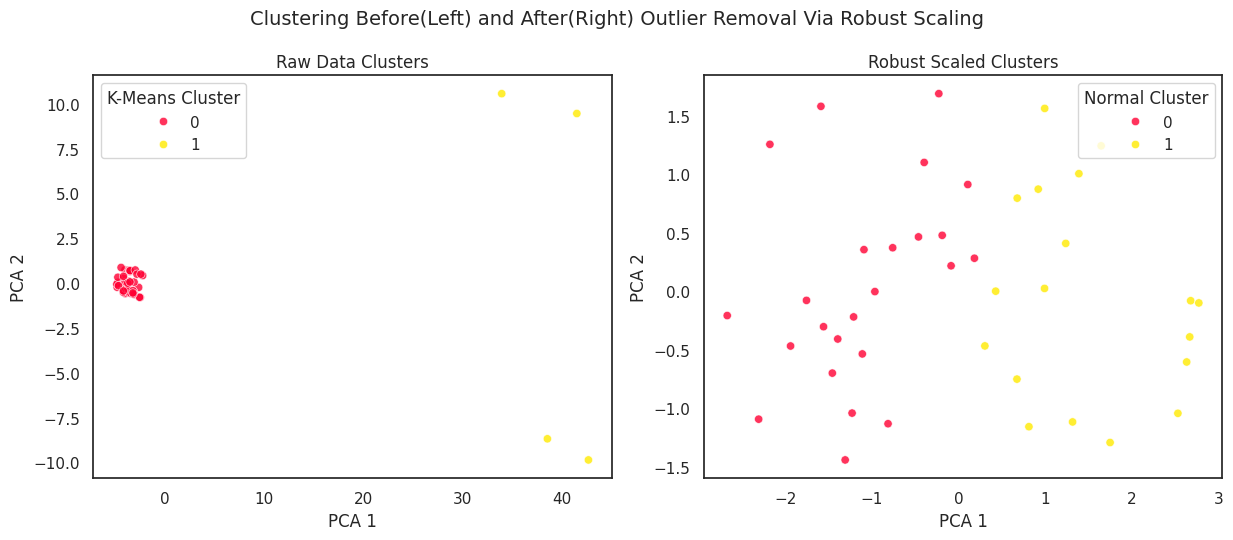

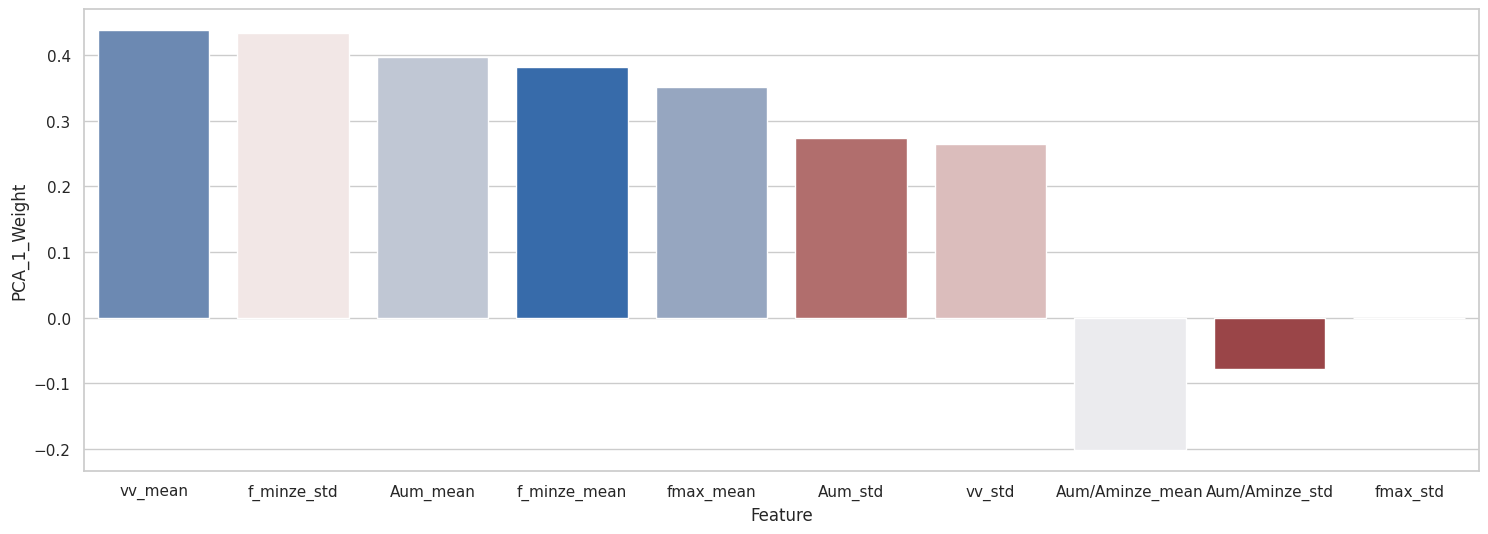

In [48]:
patient_df = pd.read_csv(DATA_PATH).drop(columns='Unnamed: 0')
grouped = patient_df.groupby('patient_id')

features = ['f_minze', 'vv', 'fmax', 'Aum', 'Aum/Aminze']
metrics = ['mean', 'std']

p_ids, col_means, col_std =[], [],[]
for p_id, g in grouped:
    X = g[features].values
    X_mean = X.mean(axis=0)
    X_std = X.std(axis=0)

    # append to the respective collections
    col_means.append(X_mean)
    col_std.append(X_std)
    p_ids.append(p_id)


feature_colls = np.hstack([col_means, col_std])
cols = [f'{col}_{metric}' for metric in metrics for col in features]

feature_df = pd.DataFrame(data=feature_colls, columns=cols)
feature_df['patient_id'] = p_ids

scaler = RobustScaler()
X_scaled = scaler.fit_transform(feature_df[cols].values)

# perform the clustering 
kmeans = KMeans(n_clusters=2, random_state=42)
labels_kmeans = kmeans.fit_predict(X_scaled)

# Reduce dimensions
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# isolate the outliers
normal_mask = X_pca[:, 0] < 10
feature_df_normal = feature_df[normal_mask]
feature_df_outliers = feature_df[~normal_mask]
print(f"Isolated {len(feature_df_outliers)} severe outliers.")


# Rerun the pca dimension reduction
scaler = RobustScaler()
X_scaled_normal = scaler.fit_transform(feature_df_normal[cols].values)
kmeans = KMeans(n_clusters=2, random_state=4)
labels_normal = kmeans.fit_predict(X_scaled_normal)
pca = PCA(n_components=2)
X_pca_norm = pca.fit_transform(X_scaled_normal)


# Set a clean seaborn background style
sns.set_theme(style="white")
fig, ax = plt.subplots(1, 2)
fig.set_size_inches(12.5, 5.5)
ax = ax.flatten()
custom_palette = ["#FF0033", "#FFEA00"]
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], 
                hue=labels_kmeans, palette=custom_palette, 
                alpha=0.8, edgecolor="w",ax=ax[0])
ax[0].set_title('Raw Data Clusters')
ax[0].set_xlabel('PCA 1')
ax[0].set_ylabel('PCA 2')
ax[0].legend(title="K-Means Cluster")
sns.scatterplot(x=X_pca_norm[:, 0], y=X_pca_norm[:, 1], 
                hue=labels_normal, palette=custom_palette, 
                alpha=0.8, edgecolor="w",ax=ax[1])
ax[1].set_title('Robust Scaled Clusters')
ax[1].set_xlabel('PCA 1')
ax[1].set_ylabel('PCA 2')
ax[1].legend(title="Normal Cluster")

# Global configurations
fig.suptitle('Clustering Before(Left) and After(Right) Outlier Removal Via Robust Scaling', fontsize=14, y=0.98)
plt.tight_layout()
plt.show()


# Create a DataFrame showing the importance of each feature for PCA 1
loadings = pd.DataFrame({
    'Feature': cols,
    'PCA_1_Weight': pca.components_[0]
})

# Sort by absolute weight to see the most influential factors
loadings['Abs_Weight'] = loadings['PCA_1_Weight'].abs()
loadings = loadings.sort_values(by='Abs_Weight', ascending=False)

plt.figure(figsize=(18, 6))
sns.set_theme(style="whitegrid")
sns.barplot(
    x=loadings['Feature'], 
    y=loadings['PCA_1_Weight'], 
    hue=loadings.index,  # Assign hue to avoid deprecation warning
    palette="vlag", 
    legend=False
)
plt.show()

In [24]:
feature_df_outliers

,f_minze_mean,vv_mean,fmax_mean,Aum_mean,Aum/Aminze_mean,f_minze_std,vv_std,fmax_std,Aum_std,Aum/Aminze_std,patient_id
27,12.321556,332.68,25.82,8498394.95,510.91,7.767719,0.000000e+00,3.552714e-15,3.725290e-09,0.000000e+00,v55
28,13.357700,400.73,35.20,11474479.34,572.69,9.032771,0.000000e+00,7.105427e-15,3.725290e-09,1.136868e-13,v56
29,14.210000,426.30,25.00,12126925.81,568.94,8.133423,1.136868e-13,0.000000e+00,0.000000e+00,1.136868e-13,v57
30,10.551613,327.10,22.00,11123075.22,680.10,6.810967,5.684342e-14,0.000000e+00,0.000000e+00,0.000000e+00,v58


## Computation based on old procedure

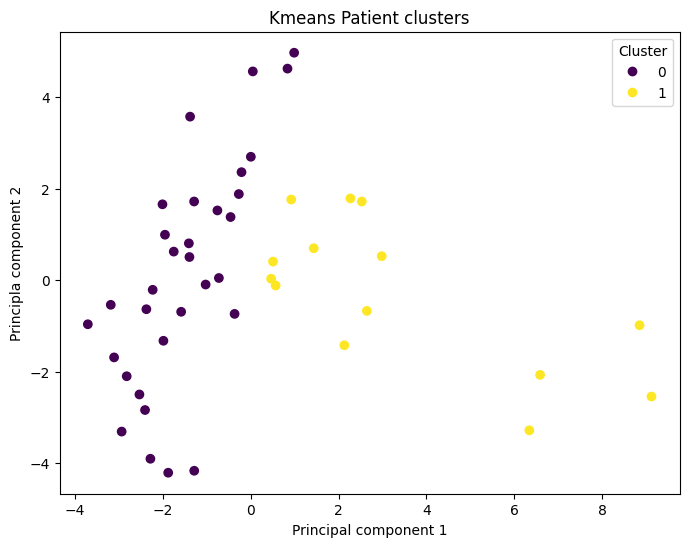

In [30]:
df = pd.read_csv(DATA_PATH)
# Building patient features
patient_features = []
for pid, g in df.groupby('patient_id'):
    feat = {}

    # static features
    feat['patient_id'] = pid
    feat['vv'] = g['vv'].iloc[0]
    feat['fmax'] = g['fmax'].iloc[0]
    feat['Aum_Aminze'] = g['Aum/Aminze'].iloc[0]

    #  compute signal statistcis
    for col in ['f_um', 'f_oppo', 'f_phone']:
        feat[f'{col}_mean'] = g[col].mean()
        feat[f'{col}_std'] = g[col].std()
        feat[f'{col}_max'] = g[col].max()
        feat[f'{col}_min'] = g[col].min()
        feat[f'{col}_skew'] = skew(g[col])
        feat[f'{col}_kurtosis'] = kurtosis(g[col])

        # area under curve
        feat[f'{col}_auc'] = np.trapezoid(g[col])

        # slope
        feat[f'{col}_slope'] = np.polyfit(
            np.arange(len(g[col])),
            g[col],
            1
        )[0]
    patient_features.append(feat)
patient_df = pd.DataFrame(patient_features)

# normalize features
X = patient_df.drop(columns=['patient_id'])
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)



kmeans = KMeans(n_clusters=2, random_state=42) # create k_means obj of 2 clusters
gmm = GaussianMixture(n_components=2, random_state=42) 
clusters_means = kmeans.fit_predict(X_scaled)
clusters_gmm = gmm.fit_predict(X_scaled)

patient_df['clusters_kmeans'] = clusters_means
patient_df['clusters_gmm'] = clusters_gmm
# pca computations
pca = PCA(n_components=2)
x_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(x_pca[:, 0], x_pca[:, 1], c=patient_df['clusters_kmeans'])
plt.xlabel('Principal component 1')
plt.ylabel('Principla component 2')
plt.title('Kmeans Patient clusters')
plt.legend(*scatter.legend_elements(), title='Cluster')
plt.savefig('kmeans_patient_clusters.png')
plt.show()

# sampling patients for uroflow medic prep
cluster_0_mask = patient_df['clusters_kmeans'] == 0
cluster_0_patients = patient_df[cluster_0_mask]['patient_id']
cluster_1_patients = patient_df[~cluster_0_mask]['patient_id']

joblib.dump(kmeans, 'kmeans_uroflow_clustering_model.pkl')
joblib.dump(gmm, 'gmm_uroflow_clustering_model.pkl')
cluster_1_patients.to_csv('class_one_patients.csv')
cluster_0_patients.to_csv('class_1_patients.csv')

# Pseudo Labeling the patients

In [18]:
# Expert annotations
pos_labels = ['v77']
neg_labels = ['v59', 'v23', 'v54', 'v57']

cols = ['vv', 'fmax', 'Aum_Aminze', 'f_um_mean', 'f_um_std',
       'f_um_max', 'f_um_min', 'f_um_skew', 'f_um_kurtosis', 'f_um_auc',
       'f_um_slope', 'f_oppo_mean', 'f_oppo_std', 'f_oppo_max', 'f_oppo_min',
       'f_oppo_skew', 'f_oppo_kurtosis', 'f_oppo_auc', 'f_oppo_slope',
       'f_phone_mean', 'f_phone_std', 'f_phone_max', 'f_phone_min',
       'f_phone_skew', 'f_phone_kurtosis', 'f_phone_auc', 'f_phone_slope']

cols = patient_df.columns.drop('patient_id')
pos_expert_index = patient_df.loc[patient_df['patient_id'] == pos_labels[0]].index
neg_expert_index = patient_df.loc[patient_df['patient_id'] == neg_labels[0]].index



X = patient_df[cols]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Extract the vectors
pos_gt_vector = X_scaled[pos_expert_index]
neg_gt_vector = X_scaled[neg_expert_index]

# compute distance to centroids of these points
dist_to_pos = np.linalg.norm(X_scaled - pos_gt_vector, axis=1)
dist_to_neg = np.linalg.norm(X_scaled - neg_gt_vector, axis= 1)

# propagate the labels
patient_df_copy = patient_df.copy()
patient_df_copy['pseudo_label'] = np.where(dist_to_pos < dist_to_neg, 'Positive', 'Negative')

neg_indices = [(patient_df_copy.loc[patient_df_copy['patient_id'] == idx].index)[0] for idx in neg_labels]
patient_df_copy.iloc[neg_indices, :]

,patient_id,vv,fmax,Aum_Aminze,f_um_mean,f_um_std,f_um_max,f_um_min,f_um_skew,f_um_kurtosis,...,f_oppo_slope,f_phone_mean,f_phone_std,f_phone_max,f_phone_min,f_phone_skew,f_phone_kurtosis,f_phone_auc,f_phone_slope,pseudo_label
31,v59,285.5,22.0,56.66,674.007103,457.177086,1371.0076,0.0,-0.235155,-1.407842,...,-0.033234,1222.400998,755.609660,2297.484974,0.000000,-0.363276,-1.294946,293352.758848,-0.982453,Negative
7,v23,346.9,22.0,43.68,488.798655,319.723699,950.1649,0.0,-0.488963,-1.336690,...,-0.646631,1119.328801,709.953454,2179.817193,0.000000,-0.459357,-1.320648,346978.869735,-3.855354,Positive
26,v54,155.9,17.0,56.70,420.965270,287.761187,792.7898,0.0,-0.370413,-1.578926,...,-0.381063,881.110931,574.824871,1605.023164,0.000000,-0.380060,-1.535104,185010.513578,-2.263896,Positive
29,v57,426.3,25.0,568.94,8084.736571,4910.743592,17237.1863,0.0,-0.317783,-0.859793,...,-0.530531,1113.366037,642.348066,2239.026058,9.326378,-0.433211,-0.893490,333982.543215,-4.293919,Positive
